## Experiment 1 — Weight Recovery: 3-Point Stencil (2nd Order)
Proof that we should get the same as the FD stencil if we use the following matrix inversion:
$$
\begin{bmatrix}
1 & 1  & 1 \\
\Delta x_1 & \Delta x_2  & \Delta x_3 \\
\alpha \Delta t_1 + \tfrac{1}{2}\Delta x_1^2 & \alpha \Delta t_2 + \tfrac{1}{2}\Delta x_2^2 &  \alpha \Delta t_n + \tfrac{1}{2}\Delta x_3^2
\end{bmatrix}
\begin{bmatrix} w_1 \\ w_2  \\ w_3 \end{bmatrix}
=
\begin{bmatrix} 1 \\ 0 \\ 0 \end{bmatrix}
$$

$$
u^* = \sum_{i=1}^{n} w_i \, u_i
$$
### Constraint System $Aw = b$
Three rows are imposed:
1. weights sum to 1
2. eliminates first-order spatial error
3. substitutes $u_t = \alpha u_{xx}$ via the combined row
   $\alpha \Delta t_i + \tfrac{1}{2}\Delta x_i^2$

In [3]:
import numpy as np

# Parameters
alpha = 0.1
nx = 20
nt = 100
x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

r = 0.04  # CFL number
dt = r * dx**2 / alpha

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.6f}")
print(f"CFL r = alpha*dt/dx^2 = {alpha * dt / dx**2:.4f}")

# Pick one target point: interior, second time step
# target: (x*, t*) = (x[5], t[1])
j_star = 5
k_star = 1

x_star = x[j_star]
t_star = dt * k_star

print(f"\nTarget point: x* = {x_star:.4f}, t* = {t_star:.6f}")

# 3 neighbours (all at previous time step k=0)
# n1: centre  (x*,       t* - dt)
# n2: left    (x* - dx,  t* - dt)
# n3: right   (x* + dx,  t* - dt)
dx_nb = np.array([0.0, -dx, dx])
dt_nb = np.array([-dt, -dt, -dt])

print("\nNeighbours (relative offsets):")
print(f"  Centre: dx = {dx_nb[0]:.4f}, dt = {dt_nb[0]:.6f}")
print(f"  Left:   dx = {dx_nb[1]:.4f}, dt = {dt_nb[1]:.6f}")
print(f"  Right:  dx = {dx_nb[2]:.4f}, dt = {dt_nb[2]:.6f}")

# Build 3x3 matrix A and solve
# Row 1: consistency   sum(w) = 1
# Row 2: spatial bias  sum(w*dx) = 0
# Row 3: diffusion     sum(w*(alpha*dt + 0.5*dx^2)) = 0
A = np.array([
    [1.0, 1.0, 1.0],
    dx_nb,
    alpha * dt_nb + 0.5 * dx_nb**2
])
b = np.array([1.0, 0.0, 0.0])

print("\nMatrix A:")
print(A)
print(f"\nb = {b}")

w = np.linalg.solve(A, b)

# FD weights (explicit Euler)
# u* = (1 - 2r)*u_c + r*u_l + r*u_r
w_fd = np.array([1 - 2 * r, r, r])

print("\nWeight Comparison")
print(f"{'':10s} {'Centre':>12} {'Left':>12} {'Right':>12}")
print(f"{'Our w':10s} {w[0]:>12.8f} {w[1]:>12.8f} {w[2]:>12.8f}")
print(f"{'FD w':10s} {w_fd[0]:>12.8f} {w_fd[1]:>12.8f} {w_fd[2]:>12.8f}")
print(f"{'Diff':10s} {w[0] - w_fd[0]:>12.2e} {w[1] - w_fd[1]:>12.2e} {w[2] - w_fd[2]:>12.2e}")

# Apply weights to reconstruct u at target
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

u_nb = np.array([
    u_true(x_star, t_star - dt),
    u_true(x_star - dx, t_star - dt),
    u_true(x_star + dx, t_star - dt),
])

u_pred = w @ u_nb
u_fd = w_fd @ u_nb
u_exact = u_true(x_star, t_star)

print("\nReconstruction at target")
print(f"u_pred  (our weights) = {u_pred:.8f}")
print(f"u_fd    (FD weights)  = {u_fd:.8f}")
print(f"u_exact (true)        = {u_exact:.8f}")
print(f"Error our vs exact    = {abs(u_pred - u_exact):.4e}")
print(f"Error FD vs exact     = {abs(u_fd - u_exact):.4e}")
print(f"Error our vs FD       = {abs(u_pred - u_fd):.4e}")

dx = 0.052632
dt = 0.001108
CFL r = alpha*dt/dx^2 = 0.0400

Target point: x* = 0.2632, t* = 0.001108

Neighbours (relative offsets):
  Centre: dx = 0.0000, dt = -0.001108
  Left:   dx = -0.0526, dt = -0.001108
  Right:  dx = 0.0526, dt = -0.001108

Matrix A:
[[ 1.00000000e+00  1.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00 -5.26315789e-02  5.26315789e-02]
 [-1.10803324e-04  1.27423823e-03  1.27423823e-03]]

b = [1. 0. 0.]

Weight Comparison
                 Centre         Left        Right
Our w        0.92000000   0.04000000   0.04000000
FD w         0.92000000   0.04000000   0.04000000
Diff          -1.11e-16    -6.94e-18    -6.94e-18

Reconstruction at target
u_pred  (our weights) = 0.73492117
u_fd    (FD weights)  = 0.73492117
u_exact (true)        = 0.73491977
Error our vs exact    = 1.3916e-06
Error FD vs exact     = 1.3916e-06
Error our vs FD       = 2.2204e-16


## Experiment 2 — Full Rollout: 3-Point Stencil (2nd Order)

**Setup:** $u_t = \alpha u_{xx}$, $\alpha = 0.1$, CFL $r = 0.4$, $T = 1.097$, uniform grid.
3 neighbours, 3 constraints (consistency + kill $u_x$ + PDE).
 
Method is **algebraically identical** to explicit Euler FD at this stencil size.

dx = 0.0526,  dt = 0.011080,  CFL r = alpha*dt/dx^2 = 0.4000
T  = 1.0970

Step 1: Weight Recovery
                          centre        left       right
Our weights             0.200000    0.400000    0.400000
FD weights              0.200000    0.400000    0.400000
Difference              0.00e+00    0.00e+00    0.00e+00

Step 2: Full Rollout Error
Our vs True  - mean: 5.2427e-04  max: 1.1738e-03
FD  vs True  - mean: 5.2427e-04  max: 1.1738e-03
Our vs FD    - mean: 5.9890e-17  max: 3.3307e-16


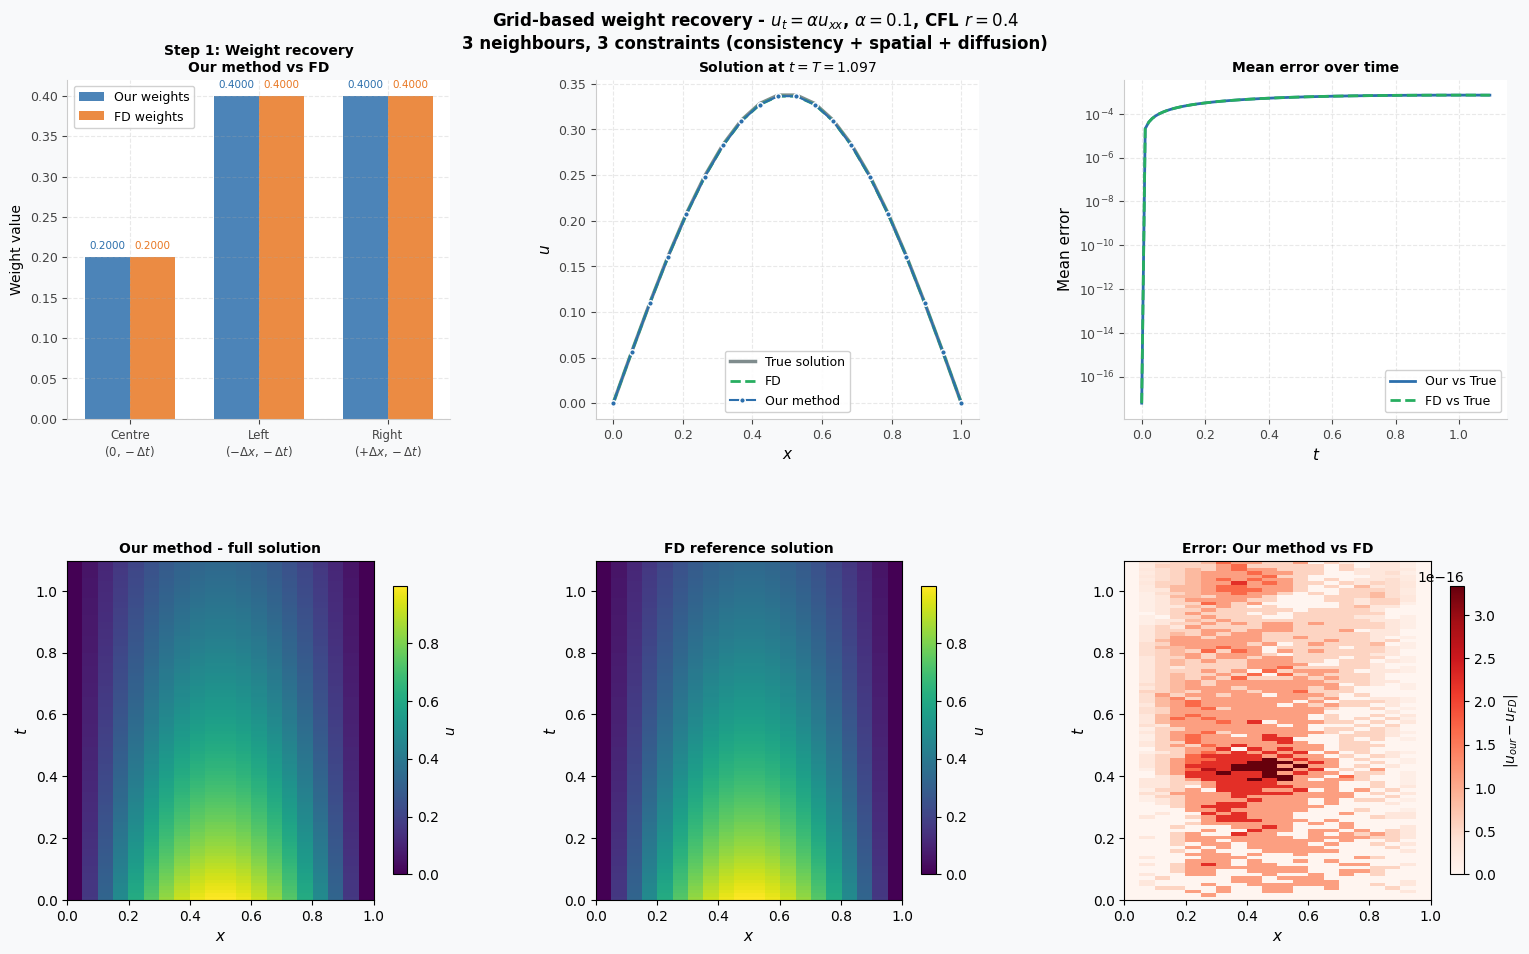

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx = 20
nt = 100
x = np.linspace(0, 1, nx)
dx = x[1] - x[0]

# pick dt to satisfy CFL
r = 0.4
dt = r * dx**2 / alpha
t = np.linspace(0, dt * (nt - 1), nt)
T = t[-1]

print(f"dx = {dx:.4f},  dt = {dt:.6f},  CFL r = alpha*dt/dx^2 = {alpha*dt/dx**2:.4f}")
print(f"T  = {T:.4f}")

# --------------------------------------------------
# True solution
# --------------------------------------------------
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# --------------------------------------------------
# FD reference solution (explicit Euler)
# --------------------------------------------------
U_fd = np.zeros((nt, nx))
U_fd[0, :] = u_true(x, 0)
U_fd[:, 0] = 0.0
U_fd[:, -1] = 0.0

for k in range(nt - 1):
    U_fd[k+1, 1:-1] = (
        U_fd[k, 1:-1]
        + r * (U_fd[k, 2:] - 2 * U_fd[k, 1:-1] + U_fd[k, :-2])
    )

# --------------------------------------------------
# Weight solver
# 3 neighbours: centre, left, right (previous timestep)
# 3 constraints: consistency, no spatial bias, diffusion
# --------------------------------------------------
def compute_weights_grid(dx, dt, alpha):

    dx_nb = np.array([0.0, -dx, +dx])
    dt_nb = np.array([-dt, -dt, -dt])

    A = np.array([
        [1.0, 1.0, 1.0],
        dx_nb,
        alpha * dt_nb + 0.5 * dx_nb**2
    ])

    b = np.array([1.0, 0.0, 0.0])

    w = np.linalg.solve(A, b)

    return w, dx_nb, dt_nb


w, dx_nb, dt_nb = compute_weights_grid(dx, dt, alpha)

# --------------------------------------------------
# Compare with known FD weights
# Explicit Euler: u* = (1-2r)*u_c + r*u_l + r*u_r
# --------------------------------------------------
w_fd = np.array([1 - 2 * r, r, r])

print("\nStep 1: Weight Recovery")
print(f"{'':20s}  {'centre':>10}  {'left':>10}  {'right':>10}")
print(f"{'Our weights':20s}  {w[0]:>10.6f}  {w[1]:>10.6f}  {w[2]:>10.6f}")
print(f"{'FD weights':20s}  {w_fd[0]:>10.6f}  {w_fd[1]:>10.6f}  {w_fd[2]:>10.6f}")
print(f"{'Difference':20s}  {w[0]-w_fd[0]:>10.2e}  {w[1]-w_fd[1]:>10.2e}  {w[2]-w_fd[2]:>10.2e}")

# --------------------------------------------------
# Full rollout using our weights
# --------------------------------------------------
U_our = np.zeros((nt, nx))

U_our[0, :] = u_true(x, 0)
U_our[:, 0] = 0.0
U_our[:, -1] = 0.0

for k in range(nt - 1):
    for j in range(1, nx - 1):

        u_nb = np.array([
            U_our[k, j],
            U_our[k, j-1],
            U_our[k, j+1]
        ])

        U_our[k+1, j] = w @ u_nb


print("\nStep 2: Full Rollout Error")

err_our_vs_true = np.abs(U_our - u_true(*np.meshgrid(x, t)))
err_fd_vs_true = np.abs(U_fd - u_true(*np.meshgrid(x, t)))
err_our_vs_fd = np.abs(U_our - U_fd)

print(f"Our vs True  - mean: {err_our_vs_true.mean():.4e}  max: {err_our_vs_true.max():.4e}")
print(f"FD  vs True  - mean: {err_fd_vs_true.mean():.4e}  max: {err_fd_vs_true.max():.4e}")
print(f"Our vs FD    - mean: {err_our_vs_fd.mean():.4e}  max: {err_our_vs_fd.max():.4e}")

# --------------------------------------------------
# Plotting
# --------------------------------------------------
BLUE = '#2C6FAC'
RED = '#C0392B'
GREEN = '#27AE60'
ORANGE = '#E87722'
GREY = '#7F8C8D'


def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')


fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    hspace=0.42,
    wspace=0.38,
    left=0.07,
    right=0.97,
    top=0.90,
    bottom=0.08
)

# Panel 1: Weight bar chart
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)

labels = [
    'Centre\n$(0, -\\Delta t)$',
    'Left\n$(-\\Delta x, -\\Delta t)$',
    'Right\n$(+\\Delta x, -\\Delta t)$'
]

xpos = np.arange(3)
width = 0.35

ax1.bar(xpos - width/2, w, width, color=BLUE, label='Our weights', alpha=0.85)
ax1.bar(xpos + width/2, w_fd, width, color=ORANGE, label='FD weights', alpha=0.85)

ax1.set_xticks(xpos)
ax1.set_xticklabels(labels, fontsize=8.5)

ax1.set_ylabel('Weight value', fontsize=10)
ax1.set_title('Step 1: Weight recovery\nOur method vs FD', fontsize=10, fontweight='bold')

ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

for i, (wo, wf) in enumerate(zip(w, w_fd)):
    ax1.text(i - width/2, wo + 0.01, f'{wo:.4f}', ha='center', fontsize=7.5, color=BLUE)
    ax1.text(i + width/2, wf + 0.01, f'{wf:.4f}', ha='center', fontsize=7.5, color=ORANGE)

# Panel 2: Solution at final time
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)

ax2.plot(x, u_true(x, T), '-', color=GREY, linewidth=2.5, label='True solution')
ax2.plot(x, U_fd[-1, :], '--', color=GREEN, linewidth=2, label='FD')
ax2.plot(
    x, U_our[-1, :],
    'o-',
    color=BLUE,
    linewidth=1.5,
    markersize=4,
    label='Our method',
    markeredgecolor='white'
)

ax2.set_xlabel('$x$', fontsize=11)
ax2.set_ylabel('$u$', fontsize=11)

ax2.set_title(f'Solution at $t = T = {T:.3f}$', fontsize=10, fontweight='bold')

ax2.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# Panel 3: Error vs time
ax3 = fig.add_subplot(gs[0, 2])
style_ax(ax3)

err_our_t = err_our_vs_true.mean(axis=1)
err_fd_t = err_fd_vs_true.mean(axis=1)

ax3.semilogy(t, err_our_t, '-', color=BLUE, linewidth=2, label='Our vs True')
ax3.semilogy(t, err_fd_t, '--', color=GREEN, linewidth=2, label='FD vs True')

ax3.set_xlabel('$t$', fontsize=11)
ax3.set_ylabel('Mean error', fontsize=11)

ax3.set_title('Mean error over time', fontsize=10, fontweight='bold')

ax3.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

# Panel 4: Our solution heatmap
ax4 = fig.add_subplot(gs[1, 0])

im4 = ax4.imshow(
    U_our,
    origin='lower',
    aspect='auto',
    extent=[0, 1, 0, T],
    cmap='viridis'
)

plt.colorbar(im4, ax=ax4, label='$u$', shrink=0.85)

ax4.set_xlabel('$x$', fontsize=11)
ax4.set_ylabel('$t$', fontsize=11)

ax4.set_title('Our method - full solution', fontsize=10, fontweight='bold')

# Panel 5: FD solution heatmap
ax5 = fig.add_subplot(gs[1, 1])

im5 = ax5.imshow(
    U_fd,
    origin='lower',
    aspect='auto',
    extent=[0, 1, 0, T],
    cmap='viridis'
)

plt.colorbar(im5, ax=ax5, label='$u$', shrink=0.85)

ax5.set_xlabel('$x$', fontsize=11)
ax5.set_ylabel('$t$', fontsize=11)

ax5.set_title('FD reference solution', fontsize=10, fontweight='bold')

# Panel 6: Error heatmap
ax6 = fig.add_subplot(gs[1, 2])

im6 = ax6.imshow(
    err_our_vs_fd,
    origin='lower',
    aspect='auto',
    extent=[0, 1, 0, T],
    cmap='Reds'
)

plt.colorbar(im6, ax=ax6, label='$|u_{our} - u_{FD}|$', shrink=0.85)

ax6.set_xlabel('$x$', fontsize=11)
ax6.set_ylabel('$t$', fontsize=11)

ax6.set_title('Error: Our method vs FD', fontsize=10, fontweight='bold')

fig.suptitle(
    r'Grid-based weight recovery - $u_t = \alpha u_{xx}$, $\alpha=0.1$, CFL $r=0.4$'
    '\n'
    r'3 neighbours, 3 constraints (consistency + spatial + diffusion)',
    fontsize=12,
    fontweight='bold',
    y=0.97
)

plt.show()

## Experiment 3 — Weight Recovery: 5-Point Stencil (4th Order)

**Setup:** $u_t = \alpha u_{xx}$ uniform grid.5 neighbours, 5 constraints (consistency + kill $u_x$ + PDE + kill $u_{xxx}$ + kill $u_{xxxx}$).
Didn't add the constraint on $\Delta t$ because all neighbours have the same $\Delta t$,
making $\sum_i w_i \Delta t_i = -\Delta t \sum_i w_i = -\Delta t$ automatically satisfied via consistency.

**Results:**
- Weights match 4th order FD weights to machine precision (diff $\sim 10^{-16}$)
- Reconstruction error vs exact: $2.43 \times 10^{-6}$
- Our method vs FD: $\sim 10^{-16}$ (machine precision)

Recovered weights: $(0,\ \tfrac{8}{15},\ \tfrac{8}{15},\ -\tfrac{1}{30},\ -\tfrac{1}{30})$,
consistent with the classical 4th order explicit stencil.

In [7]:
import numpy as np

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx    = 40
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.4
dt    = r * dx**2 / alpha

print(f"dx = {dx:.6f}")
print(f"dt = {dt:.8f}")
print(f"CFL r = alpha*dt/dx^2 = {alpha*dt/dx**2:.4f}")

# --------------------------------------------------
# Target point
# --------------------------------------------------
j_star = 10
k_star = 1

x_star = x[j_star]
t_star = dt * k_star

print(f"\nTarget: x* = {x_star:.6f},  t* = {t_star:.8f}")

# --------------------------------------------------
# 5 neighbours (all at previous time step)
# order: centre, left1, right1, left2, right2
# --------------------------------------------------
dx_nb = np.array([0.0, -dx, +dx, -2*dx, +2*dx])
dt_nb = np.array([-dt, -dt,  -dt,  -dt,   -dt])

print(f"\nNeighbours (dx, dt):")
labels = ['Centre', 'Left 1', 'Right 1', 'Left 2', 'Right 2']
for lab, dxi, dti in zip(labels, dx_nb, dt_nb):
    print(f"  {lab:8s}: dx={dxi:+.6f},  dt={dti:.8f}")

# --------------------------------------------------
# Build 5x5 matrix
# Row 1: consistency
# Row 2: kills u_x
# Row 3: PDE constraint  (1/2 dx^2 - alpha dt)
# Row 4: kills u_xxx
# Row 5: kills u_xxxx  -> gives 4th order
# --------------------------------------------------
A = np.array([
    np.ones(5),
    dx_nb,
    0.5 * dx_nb**2 + alpha * dt_nb,
    dx_nb**3 / 6,
    dx_nb**4 / 24,
])
b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])

print(f"\nMatrix A:")
print(np.array2string(A, formatter={'float_kind': lambda x: f'{x:+.6e}'}))
print(f"\nb = {b}")

w = np.linalg.solve(A, b)

# --------------------------------------------------
# Theoretical 4th order FD weights
# u* = (1 - 5r/2)*u_c + (4r/3)*(u_l1+u_r1) + (-r/12)*(u_l2+u_r2)
# --------------------------------------------------
w_fd = np.array([
    1 - 5*r/2,      # centre
     4*r/3,         # left 1
     4*r/3,         # right 1
    -r/12,          # left 2
    -r/12,          # right 2
])

print(f"\n--- Weight Comparison --------------------------------------")
print(f"{'':12s}  {'Centre':>14}  {'Left 1':>14}  {'Right 1':>14}  {'Left 2':>14}  {'Right 2':>14}")
print(f"{'Our w':12s}  {w[0]:>14.8f}  {w[1]:>14.8f}  {w[2]:>14.8f}  {w[3]:>14.8f}  {w[4]:>14.8f}")
print(f"{'FD w':12s}  {w_fd[0]:>14.8f}  {w_fd[1]:>14.8f}  {w_fd[2]:>14.8f}  {w_fd[3]:>14.8f}  {w_fd[4]:>14.8f}")
print(f"{'Diff':12s}  {w[0]-w_fd[0]:>14.2e}  {w[1]-w_fd[1]:>14.2e}  {w[2]-w_fd[2]:>14.2e}  {w[3]-w_fd[3]:>14.2e}  {w[4]-w_fd[4]:>14.2e}")

# --------------------------------------------------
# Reconstruct u at target
# --------------------------------------------------
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

u_nb = np.array([
    u_true(x_star,          t_star - dt),
    u_true(x_star - dx,     t_star - dt),
    u_true(x_star + dx,     t_star - dt),
    u_true(x_star - 2*dx,   t_star - dt),
    u_true(x_star + 2*dx,   t_star - dt),
])

u_pred  = w    @ u_nb
u_fd    = w_fd @ u_nb
u_exact = u_true(x_star, t_star)

print(f"\n--- Reconstruction at target -------------------------------")
print(f"u_pred  (our weights) = {u_pred:.10f}")
print(f"u_fd    (FD  weights) = {u_fd:.10f}")
print(f"u_exact (true)        = {u_exact:.10f}")
print(f"Error our vs exact    = {abs(u_pred  - u_exact):.4e}")
print(f"Error FD  vs exact    = {abs(u_fd    - u_exact):.4e}")
print(f"Error our vs FD       = {abs(u_pred  - u_fd):.4e}")

dx = 0.025641
dt = 0.00262985
CFL r = alpha*dt/dx^2 = 0.4000

Target: x* = 0.256410,  t* = 0.00262985

Neighbours (dx, dt):
  Centre  : dx=+0.000000,  dt=-0.00262985
  Left 1  : dx=-0.025641,  dt=-0.00262985
  Right 1 : dx=+0.025641,  dt=-0.00262985
  Left 2  : dx=-0.051282,  dt=-0.00262985
  Right 2 : dx=+0.051282,  dt=-0.00262985

Matrix A:
[[+1.000000e+00 +1.000000e+00 +1.000000e+00 +1.000000e+00 +1.000000e+00]
 [+0.000000e+00 -2.564103e-02 +2.564103e-02 -5.128205e-02 +5.128205e-02]
 [-2.629849e-04 +6.574622e-05 +6.574622e-05 +1.051940e-03 +1.051940e-03]
 [+0.000000e+00 -2.809668e-06 +2.809668e-06 -2.247734e-05 +2.247734e-05]
 [+0.000000e+00 +1.801069e-08 +1.801069e-08 +2.881710e-07 +2.881710e-07]]

b = [1. 0. 0. 0. 0.]

--- Weight Comparison --------------------------------------
                      Centre          Left 1         Right 1          Left 2         Right 2
Our w            -0.00000000      0.53333333      0.53333333     -0.03333333     -0.03333333
FD w              0

## Experiment 4 — One-Sided 4th Order Boundary Stencils

**Setup:** Same as Experiment 3 but for points near the boundary ($j=1$ and $j=N-2$)
where the symmetric 5-point stencil would reach outside the domain.

**Interior stencil** (symmetric, offsets $-2,-1,0,+1,+2$):

**Left boundary stencil** ($j=1$, offsets $-1,0,+1,+2,+3$):

**Right boundary stencil** ($j=N-2$, offsets $-3,-2,-1,0,+1$):

All three use the same 5 constraints — the stencil is just shifted laterally.
The right stencil weights are the mirror of the left: $w_R = w_L^{\text{reversed}}$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx    = 40
nt    = 200
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.05
dt    = r * dx**2 / alpha
t     = np.linspace(0, dt * (nt - 1), nt)
T     = t[-1]

print(f"dx = {dx:.6f},  dt = {dt:.8f},  CFL r = {alpha*dt/dx**2:.4f},  T = {T:.4f}")

# --------------------------------------------------
# True solution
# --------------------------------------------------
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# --------------------------------------------------
# Weight solvers
# --------------------------------------------------
def solve_weights(dx_nb, dt_nb, alpha, order):
    """General weight solver given neighbour offsets and order (2 or 4)."""
    n = len(dx_nb)
    if order == 2:
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
        ])
        b = np.array([1.0, 0.0, 0.0])
    else:  # order == 4
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
            dx_nb**3 / 6,
            dx_nb**4 / 24,
        ])
        b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
    return np.linalg.solve(A, b)

def weights_2nd_order(dx, dt, alpha):
    """3 neighbours, 3 constraints - symmetric 2nd order"""
    dx_nb = np.array([0.0, -dx, +dx])
    dt_nb = np.array([-dt, -dt, -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=2)

def weights_4th_order(dx, dt, alpha):
    """5 neighbours, 5 constraints - symmetric 4th order (interior)"""
    dx_nb = np.array([0.0, -dx, +dx, -2*dx, +2*dx])
    dt_nb = np.array([-dt, -dt,  -dt,  -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_left(dx, dt, alpha):
    """5 neighbours - one-sided 4th order for j=1 (near left boundary).
    Neighbours: j-1, j, j+1, j+2, j+3  (offsets: -dx, 0, +dx, +2dx, +3dx)"""
    dx_nb = np.array([-dx,  0.0, +dx, +2*dx, +3*dx])
    dt_nb = np.array([-dt,  -dt, -dt,   -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_right(dx, dt, alpha):
    """5 neighbours - one-sided 4th order for j=nx-2 (near right boundary).
    Neighbours: j-3, j-2, j-1, j, j+1  (offsets: -3dx, -2dx, -dx, 0, +dx)"""
    dx_nb = np.array([-3*dx, -2*dx, -dx, 0.0, +dx])
    dt_nb = np.array([  -dt,   -dt, -dt, -dt,  -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

# compute weights once (same for all points at fixed dx, dt)
w2     = weights_2nd_order(dx, dt, alpha)
w4     = weights_4th_order(dx, dt, alpha)
w4_L   = weights_4th_order_left(dx, dt, alpha)
w4_R   = weights_4th_order_right(dx, dt, alpha)

# theoretical FD weights
w2_fd = np.array([1 - 2*r, r, r])
w4_fd = np.array([1 - 5*r/2, 4*r/3, 4*r/3, -r/12, -r/12])

print(f"\n--- 2nd order weight check --------------------------------")
print(f"Our:  {w2}")
print(f"FD:   {w2_fd}")
print(f"Diff: {w2 - w2_fd}")

print(f"\n--- 4th order weight check (interior) ---------------------")
print(f"Our:  {w4}")
print(f"FD:   {w4_fd}")
print(f"Diff: {w4 - w4_fd}")

print(f"\n--- 4th order one-sided weights ---------------------------")
print(f"Left  (j=1,   offsets -1,0,+1,+2,+3): {w4_L}")
print(f"Right (j=N-2, offsets -3,-2,-1,0,+1): {w4_R}")
print(f"Are they mirrors? {np.allclose(w4_L, w4_R[::-1])}")

dx = 0.025641,  dt = 0.00032873,  CFL r = 0.0500,  T = 0.0654

--- 2nd order weight check --------------------------------
Our:  [0.9  0.05 0.05]
FD:   [0.9  0.05 0.05]
Diff: [-1.11022302e-16  6.93889390e-18  6.93889390e-18]

--- 4th order weight check (interior) ---------------------
Our:  [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
FD:   [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
Diff: [ 0.00000000e+00  2.77555756e-17  2.77555756e-17  0.00000000e+00
 -1.73472348e-18]

--- 4th order one-sided weights ---------------------------
Left  (j=1,   offsets -1,0,+1,+2,+3): [ 0.04583333  0.91666667  0.025       0.01666667 -0.00416667]
Right (j=N-2, offsets -3,-2,-1,0,+1): [-0.00416667  0.01666667  0.025       0.91666667  0.04583333]
Are they mirrors? True


## Experiment 4 — Results: 2nd vs 4th Order Full Rollout


dx = 0.025641,  dt = 0.00032873,  CFL r = 0.0500,  T = 0.6571

--- 2nd order weight check ------------------------------
Our:  [0.9  0.05 0.05]
FD:   [0.9  0.05 0.05]
Diff: [-1.11022302e-16  6.93889390e-18  6.93889390e-18]

--- 4th order weight check (interior) -------------------
Our:  [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
FD:   [ 0.875       0.06666667  0.06666667 -0.00416667 -0.00416667]
Diff: [ 0.00000000e+00  2.77555756e-17  2.77555756e-17  0.00000000e+00
 -1.73472348e-18]

--- 4th order one-sided weights -------------------------
Left  (j=1):   [ 0.04583333  0.91666667  0.025       0.01666667 -0.00416667]
Right (j=N-2): [-0.00416667  0.01666667  0.025       0.91666667  0.04583333]
Are they mirrors? True

--- Full rollout errors vs true solution -----------------
2nd order - mean: 5.0016e-05  max: 1.2826e-04
4th order - mean: 2.1471e-05  max: 5.4904e-05


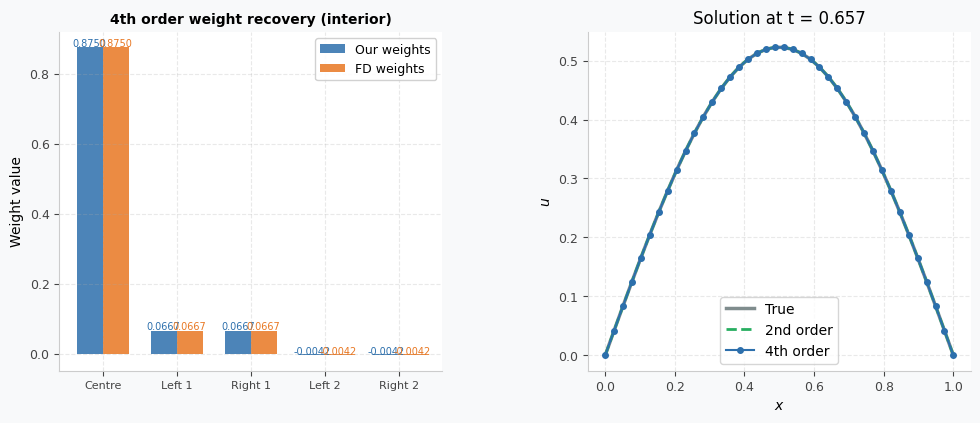

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --------------------------------------------------
# Parameters
# --------------------------------------------------
alpha = 0.1
nx    = 40
nt    = 2000
x     = np.linspace(0, 1, nx)
dx    = x[1] - x[0]

r     = 0.05
dt    = r * dx**2 / alpha
t     = np.linspace(0, dt * (nt - 1), nt)
T     = t[-1]

print(f"dx = {dx:.6f},  dt = {dt:.8f},  CFL r = {alpha*dt/dx**2:.4f},  T = {T:.4f}")

# --------------------------------------------------
# True solution
# --------------------------------------------------
def u_true(x, t):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)

# --------------------------------------------------
# Weight solvers
# --------------------------------------------------
def solve_weights(dx_nb, dt_nb, alpha, order):
    """General weight solver given neighbour offsets and order (2 or 4)."""
    n = len(dx_nb)
    if order == 2:
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
        ])
        b = np.array([1.0, 0.0, 0.0])
    else:  # order == 4
        A = np.array([
            np.ones(n),
            dx_nb,
            0.5 * dx_nb**2 + alpha * dt_nb,
            dx_nb**3 / 6,
            dx_nb**4 / 24,
        ])
        b = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
    return np.linalg.solve(A, b)

def weights_2nd_order(dx, dt, alpha):
    """3 neighbours, 3 constraints - symmetric 2nd order"""
    dx_nb = np.array([0.0, -dx, +dx])
    dt_nb = np.array([-dt, -dt, -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=2)

def weights_4th_order(dx, dt, alpha):
    """5 neighbours, 5 constraints - symmetric 4th order (interior)"""
    dx_nb = np.array([0.0, -dx, +dx, -2*dx, +2*dx])
    dt_nb = np.array([-dt, -dt,  -dt,  -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_left(dx, dt, alpha):
    """5 neighbours - one-sided 4th order for j=1 (near left boundary).
    Neighbours: j-1, j, j+1, j+2, j+3"""
    dx_nb = np.array([-dx,  0.0, +dx, +2*dx, +3*dx])
    dt_nb = np.array([-dt,  -dt, -dt,   -dt,   -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

def weights_4th_order_right(dx, dt, alpha):
    """5 neighbours - one-sided 4th order for j=nx-2 (near right boundary)."""
    dx_nb = np.array([-3*dx, -2*dx, -dx, 0.0, +dx])
    dt_nb = np.array([  -dt,   -dt, -dt, -dt,  -dt])
    return solve_weights(dx_nb, dt_nb, alpha, order=4)

w2     = weights_2nd_order(dx, dt, alpha)
w4     = weights_4th_order(dx, dt, alpha)
w4_L   = weights_4th_order_left(dx, dt, alpha)
w4_R   = weights_4th_order_right(dx, dt, alpha)

w2_fd = np.array([1 - 2*r, r, r])
w4_fd = np.array([1 - 5*r/2, 4*r/3, 4*r/3, -r/12, -r/12])

print("\n--- 2nd order weight check ------------------------------")
print(f"Our:  {w2}")
print(f"FD:   {w2_fd}")
print(f"Diff: {w2 - w2_fd}")

print("\n--- 4th order weight check (interior) -------------------")
print(f"Our:  {w4}")
print(f"FD:   {w4_fd}")
print(f"Diff: {w4 - w4_fd}")

print("\n--- 4th order one-sided weights -------------------------")
print(f"Left  (j=1):   {w4_L}")
print(f"Right (j=N-2): {w4_R}")
print(f"Are they mirrors? {np.allclose(w4_L, w4_R[::-1])}")

# --------------------------------------------------
# Full rollout
# --------------------------------------------------
U_2nd = np.zeros((nt, nx))
U_2nd[0, :] = u_true(x, 0)
U_2nd[:, 0] = 0.0
U_2nd[:,-1] = 0.0
for k in range(nt - 1):
    for j in range(1, nx - 1):
        u_nb = np.array([U_2nd[k,j], U_2nd[k,j-1], U_2nd[k,j+1]])
        U_2nd[k+1, j] = w2 @ u_nb

U_4th = np.zeros((nt, nx))
U_4th[0, :] = u_true(x, 0)
U_4th[:, 0] = 0.0
U_4th[:,-1] = 0.0

for k in range(nt - 1):
    j = 1
    u_nb = np.array([U_4th[k,j-1], U_4th[k,j], U_4th[k,j+1],
                     U_4th[k,j+2], U_4th[k,j+3]])
    U_4th[k+1, j] = w4_L @ u_nb

    j = nx - 2
    u_nb = np.array([U_4th[k,j-3], U_4th[k,j-2], U_4th[k,j-1],
                     U_4th[k,j],   U_4th[k,j+1]])
    U_4th[k+1, j] = w4_R @ u_nb

    for j in range(2, nx - 2):
        u_nb = np.array([U_4th[k,j],   U_4th[k,j-1], U_4th[k,j+1],
                         U_4th[k,j-2], U_4th[k,j+2]])
        U_4th[k+1, j] = w4 @ u_nb

# --------------------------------------------------
# Errors
# --------------------------------------------------
XX, TT = np.meshgrid(x, t)
U_ref  = u_true(XX, TT)

err_2nd = np.abs(U_2nd - U_ref)
err_4th = np.abs(U_4th - U_ref)

print("\n--- Full rollout errors vs true solution -----------------")
print(f"2nd order - mean: {err_2nd.mean():.4e}  max: {err_2nd.max():.4e}")
print(f"4th order - mean: {err_4th.mean():.4e}  max: {err_4th.max():.4e}")

# --------------------------------------------------
# Plotting
# --------------------------------------------------
BLUE   = '#2C6FAC'
GREEN  = '#27AE60'
ORANGE = '#E87722'
GREY   = '#7F8C8D'

def style_ax(ax):
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')
    ax.tick_params(colors='#444444', labelsize=9)
    ax.grid(True, alpha=0.25, linestyle='--', color='#AAAAAA')

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('#F8F9FA')
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38,
                        left=0.07, right=0.97, top=0.90, bottom=0.08)

# Panel 1
ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1)

labels4 = ['Centre', 'Left 1', 'Right 1', 'Left 2', 'Right 2']
xpos    = np.arange(5)
width   = 0.35

ax1.bar(xpos - width/2, w4, width, color=BLUE, label='Our weights', alpha=0.85)
ax1.bar(xpos + width/2, w4_fd, width, color=ORANGE, label='FD weights', alpha=0.85)

ax1.set_xticks(xpos)
ax1.set_xticklabels(labels4, fontsize=8)
ax1.set_ylabel('Weight value', fontsize=10)
ax1.set_title('4th order weight recovery (interior)', fontsize=10, fontweight='bold')
ax1.legend(fontsize=9, framealpha=0.9, edgecolor='#CCCCCC')

for i, (wo, wf) in enumerate(zip(w4, w4_fd)):
    ax1.text(i - width/2, wo + 0.002, f'{wo:.4f}', ha='center', fontsize=7, color=BLUE)
    ax1.text(i + width/2, wf + 0.002, f'{wf:.4f}', ha='center', fontsize=7, color=ORANGE)

# Panel 2
ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2)

ax2.plot(x, u_true(x, T), '-', color=GREY, linewidth=2.5, label='True')
ax2.plot(x, U_2nd[-1], '--', color=GREEN, linewidth=2, label='2nd order')
ax2.plot(x, U_4th[-1], 'o-', color=BLUE, linewidth=1.5, markersize=4, label='4th order')

ax2.set_xlabel('$x$')
ax2.set_ylabel('$u$')
ax2.set_title(f'Solution at t = {T:.3f}')
ax2.legend()

plt.show()